In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Configuration

In [2]:
DATA_PATH = "../emissions-data"

TARGET_COL = "Carbon intensity gCO₂eq/kWh (direct)"

WINDOW_SIZE = 336              # 14 days history
FORECAST_HORIZON = 24          # predict next 24 hours
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32

LOG_DIR = "logs"
MODEL_DIR = "saved_model"
TFLITE_PATH = "carbon_model.tflite"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Load & Preprocess Data

In [3]:
csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df = pd.concat((
    pd.read_csv(f, parse_dates=["Datetime (UTC)"]) for f in csv_files),
    ignore_index=True)
df = df.sort_values("Datetime (UTC)")

# Time features
df["hour"] = df["Datetime (UTC)"].dt.hour
df["day_of_year"] = df["Datetime (UTC)"].dt.dayofyear

# Cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# Differencing (SARIMA-like I component)
df["diff_1"] = df[TARGET_COL].diff(1)
df["diff_24"] = df[TARGET_COL].diff(24)

df = df.drop(columns=["Data estimated", "Country", "Zone name", "Data source", "Data estimation method"])
df = df.dropna().reset_index(drop=True)
df

,Datetime (UTC),Zone id,Carbon intensity gCO₂eq/kWh (direct),Carbon intensity gCO₂eq/kWh (Life cycle),Carbon-free energy percentage (CFE%),Renewable energy percentage (RE%),hour,day_of_year,hour_sin,hour_cos,year_sin,year_cos,diff_1,diff_24
0,2021-01-02 00:00:00,DK,138.00,216.92,79.46,65.58,0,2,0.000000,1.000000,3.442161e-02,0.999407,1.78,13.34
1,2021-01-02 01:00:00,DK,125.57,204.53,80.81,66.85,1,2,0.258819,0.965926,3.442161e-02,0.999407,-12.43,14.27
2,2021-01-02 02:00:00,DK,117.76,196.51,81.74,67.74,2,2,0.500000,0.866025,3.442161e-02,0.999407,-7.81,9.54
3,2021-01-02 03:00:00,DK,113.56,190.37,82.06,67.82,3,2,0.707107,0.707107,3.442161e-02,0.999407,-4.20,2.08
4,2021-01-02 04:00:00,DK,120.01,193.65,81.42,66.91,4,2,0.866025,0.500000,3.442161e-02,0.999407,6.45,1.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2025-12-31 19:00:00,DK,103.88,170.66,85.19,80.95,19,365,-0.965926,0.258819,6.432491e-16,1.000000,-10.96,29.31
43796,2025-12-31 20:00:00,DK,106.39,170.86,84.76,80.49,20,365,-0.866025,0.500000,6.432491e-16,1.000000,2.51,38.71
43797,2025-12-31 21:00:00,DK,87.89,140.17,87.42,80.60,21,365,-0.707107,0.707107,6.432491e-16,1.000000,-18.50,22.69
43798,2025-12-31 22:00:00,DK,77.02,123.40,88.99,82.10,22,365,-0.500000,0.866025,6.432491e-16,1.000000,-10.87,6.27


# Split Data

In [4]:
train = df[(df["Datetime (UTC)"].dt.year >= 2021) &
           (df["Datetime (UTC)"].dt.year <= 2023)]

val = df[df["Datetime (UTC)"].dt.year == 2024]
test = df[df["Datetime (UTC)"].dt.year == 2025]

# Normalization

In [5]:
target_scaler = StandardScaler()

train_target_scaled = target_scaler.fit_transform(train[[TARGET_COL]])
val_target_scaled = target_scaler.transform(val[[TARGET_COL]])
test_target_scaled = target_scaler.transform(test[[TARGET_COL]])

# Save scaler parameters for Android
scaler_params = {
    "mean": target_scaler.mean_.tolist(),
    "scale": target_scaler.scale_.tolist()
}

with open("scaler_params.json", "w") as f:
    json.dump(scaler_params, f, indent=4)

# Replace target with scaled version
train[TARGET_COL] = train_target_scaled
val[TARGET_COL] = val_target_scaled
test[TARGET_COL] = test_target_scaled

# Feature Selection

In [6]:
FEATURES = [
    TARGET_COL,
    "diff_1",
    "diff_24",
    "hour_sin",
    "hour_cos",
    "year_sin",
    "year_cos"
]

def create_dataset(data):
    x, y = [], []
    values = data[FEATURES].values
    target = data[TARGET_COL].values

    for i in range(WINDOW_SIZE, len(data) - FORECAST_HORIZON):
        x.append(values[i-WINDOW_SIZE:i])
        y.append(target[i:i+FORECAST_HORIZON])

    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train)
x_val, y_val = create_dataset(val)
x_test, y_test = create_dataset(test)

print("Train shape:", x_train.shape)
print("Val shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (25896, 336, 7)
Val shape: (8424, 336, 7)
Test shape: (8400, 336, 7)


# Build SARIMA-like Model

In [7]:
num_features = len(FEATURES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, num_features)),

    # Linear convolution → AR-like behavior
    tf.keras.layers.Conv1D(32, kernel_size=3, activation="linear"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="linear"),
    tf.keras.layers.Dense(FORECAST_HORIZON)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 334, 32)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10688)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       684,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,360 (2.62 MB)

 Trainable params: 686,360 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

# Callbacks

In [8]:
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=LOG_DIR)

csv_logger = tf.keras.callbacks.CSVLogger("training_log.csv")

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, "best_model.keras"),
    monitor="val_loss",
    save_best_only=True
)

# Train

In [9]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[tensorboard_cb, csv_logger, early_stop, checkpoint]
)

Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33.0741 - mae: 2.1433 - val_loss: 1.5767 - val_mae: 0.9407
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1923 - mae: 0.8074 - val_loss: 0.6457 - val_mae: 0.6227
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7901 - mae: 0.6770 - val_loss: 0.4574 - val_mae: 0.5233
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6106 - mae: 0.5935 - val_loss: 0.4028 - val_mae: 0.4884
Epoch 5/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5382 - mae: 0.5556 - val_loss: 0.3593 - val_mae: 0.4618
Epoch 6/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4909 - mae: 0.5296 - val_loss: 0.3397 - val_mae: 0.4477
Epoch 7/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4517 - mae: 0.5063 - val_loss: 0.3026 - val_mae: 0.4213
Epoch 8/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4141 - mae: 0.4826 - val_loss: 0.2823 - val_mae: 0.4029
Epoch 9/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - l

# Evaluate

In [10]:
y_pred_scaled = model.predict(x_test)

# Convert back to real carbon intensity
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print("Real-world MAE:", mae)
print("Real-world MSE:", mse)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step
Real-world MAE: 19.805046358470353
Real-world MSE: 702.1266676871128


# Save Model

In [11]:
model.save(os.path.join(MODEL_DIR, "final_model.keras"))

# Convert to TFLite

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved:", TFLITE_PATH)

INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpnaa4em14\assets


INFO:tensorflow:Assets written to: C:\Users\jbro9\AppData\Local\Temp\tmpnaa4em14\assets


Saved artifact at 'C:\Users\jbro9\AppData\Local\Temp\tmpnaa4em14'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 336, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  2153947432528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2153947433680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2153947433296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2153947434064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2153947432912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2153947431952: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: carbon_model.tflite


# Save Hyperparameters

In [13]:
params = {
    "window_size": WINDOW_SIZE,
    "forecast_horizon": FORECAST_HORIZON,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "features": FEATURES
}

with open("model_params.json", "w") as f:
    json.dump(params, f, indent=4)

print("Training complete.")

Training complete.


# One Random 24h Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


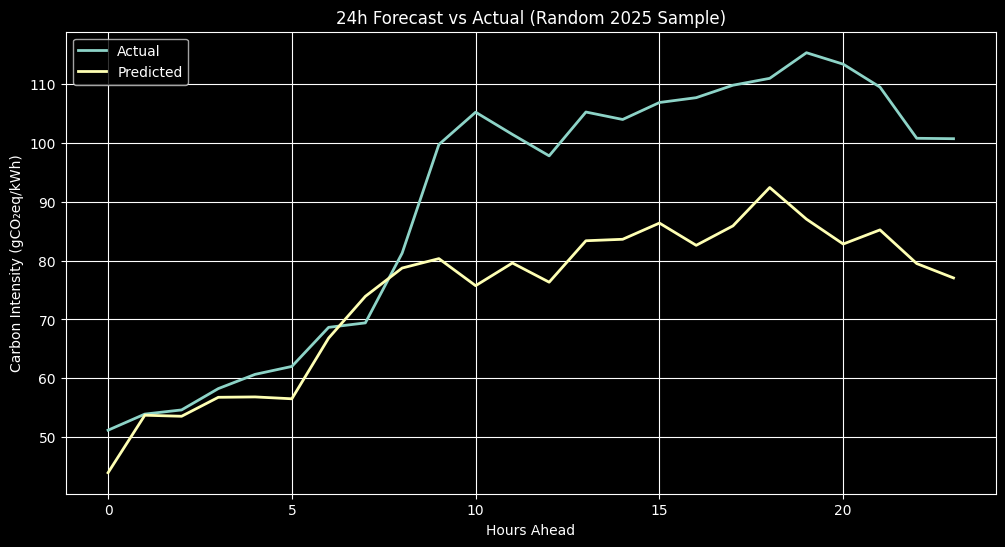

In [14]:
# Pick random test sample
idx = np.random.randint(0, len(x_test))

input_sample = x_test[idx:idx+1]
true_future_scaled = y_test[idx]

# Predict
pred_scaled = model.predict(input_sample)[0]

# Inverse scale
true_future = target_scaler.inverse_transform(
    true_future_scaled.reshape(-1, 1)
).flatten()

pred_future = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).flatten()

# Plot
plt.figure(figsize=(12, 6))
hours = np.arange(FORECAST_HORIZON)

plt.plot(hours, true_future, label="Actual", linewidth=2)
plt.plot(hours, pred_future, label="Predicted", linewidth=2)

plt.title("24h Forecast vs Actual (Random 2025 Sample)")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

# Best 3-Hour Charging Window

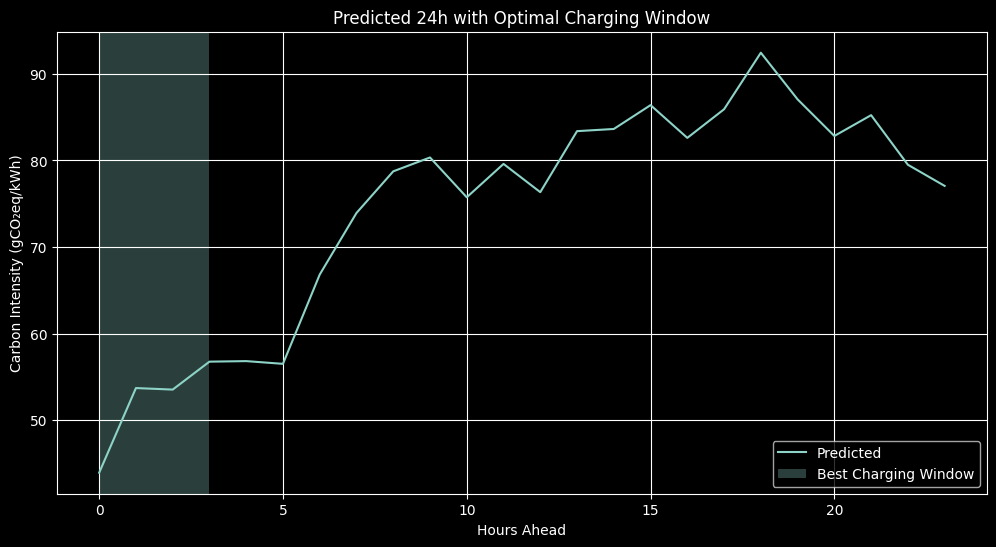

Best charging window: hour 0 to 3


In [15]:
window_size = 3

rolling_avg = np.convolve(
    pred_future,
    np.ones(window_size) / window_size,
    mode='valid'
)

best_start = np.argmin(rolling_avg)
best_end = best_start + window_size

plt.figure(figsize=(12, 6))
plt.plot(hours, pred_future, label="Predicted")

plt.axvspan(best_start, best_end,
            alpha=0.3,
            label="Best Charging Window")

plt.title("Predicted 24h with Optimal Charging Window")
plt.xlabel("Hours Ahead")
plt.ylabel("Carbon Intensity (gCO₂eq/kWh)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best charging window: hour {best_start} to {best_end}")

# Evaluate Error Per Forecast Hour

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step


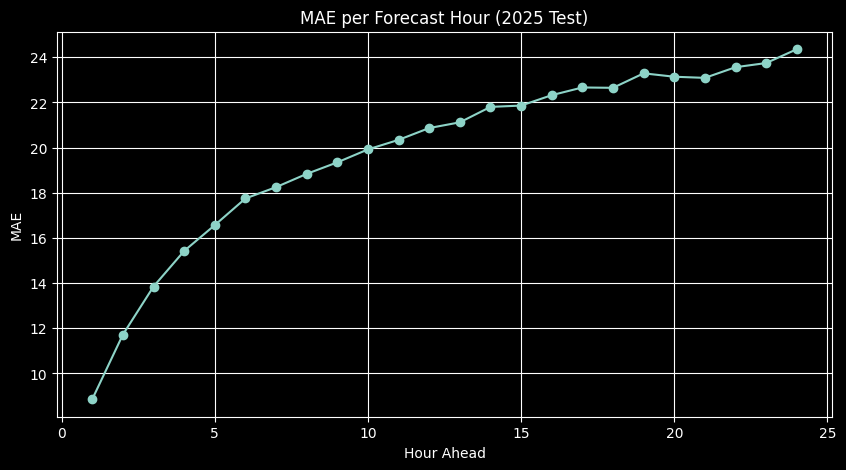

In [16]:
# Predict entire test set
pred_all_scaled = model.predict(x_test)

# Inverse scale
pred_all = target_scaler.inverse_transform(
    pred_all_scaled.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

true_all = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(-1, FORECAST_HORIZON)

# Compute MAE per forecast hour
mae_per_hour = np.mean(np.abs(pred_all - true_all), axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, FORECAST_HORIZON+1), mae_per_hour, marker='o')
plt.title("MAE per Forecast Hour (2025 Test)")
plt.xlabel("Hour Ahead")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

# Full 24h Forecast Distribution

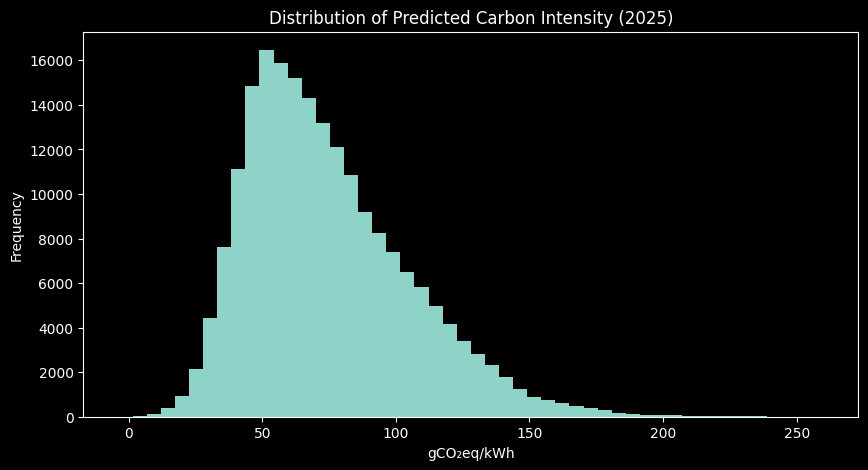

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(pred_all.flatten(), bins=50)
plt.title("Distribution of Predicted Carbon Intensity (2025)")
plt.xlabel("gCO₂eq/kWh")
plt.ylabel("Frequency")
plt.show()

# Summer vs Winter Performance

In [18]:
test_dates = test.iloc[WINDOW_SIZE:len(test)-FORECAST_HORIZON]["Datetime (UTC)"]

summer_mask = test_dates.dt.month.isin([6,7,8])
winter_mask = test_dates.dt.month.isin([12,1,2])

summer_mae = np.mean(np.abs(
    pred_all[summer_mask.values] -
    true_all[summer_mask.values]
))

winter_mae = np.mean(np.abs(
    pred_all[winter_mask.values] -
    true_all[winter_mask.values]
))

print("Summer MAE:", summer_mae)
print("Winter MAE:", winter_mae)

Summer MAE: 15.258149309843635
Winter MAE: 23.13876783884543
